In [1]:
import os
os.environ["CL_VERBOSE"]= "1"

Let's test the basic simulation elements, by running real langevin, where correct convergence is expected.  

In [3]:
from complex_langevin.simulation.state import SimState
from complex_langevin.simulation.evolution import SimEvol
from complex_langevin.models.zero_d_scalar_phi4 import SimModel
from complex_langevin.simulation.runner import SimRunner

state1 = SimState(n_seeds = int(1e4), device="cpu", dt_base = 1e-3)
model1 = SimModel(sigma=-1, lamb=1)
evol1 = SimEvol(state1, model1)
runner1 = SimRunner(state1, model1, evol1)


1767048330.691204: [SimState] initialized
1767048330.6930702: [scalar_phi4] initialized
1767048330.6932108: [SimEvol] initialized
1767048330.6933131: [SimRunner] initialized


In [4]:
import torch
from tqdm import tqdm
for _ in tqdm(range(int(1e4))):
    runner1.step()
    # print(f"{state1.alive_count} {state1.dt_ada.min()}", end = "\r")

    
runner1.finish()

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [00:06<00:00, 1662.78it/s]

1767048344.025172: [SimRunner] simulation parameters: {'sigma': -1, 'lamb': 1}
1767048344.025253: [SimRunner] Final alive count: 10000
1767048344.027361: [SimRunner] Final average of langevin time: 1.0000e+01
1767048344.028237: [SimRunner] Final std of langevin time: 1.7764e-15
1767048344.0282838: [SimRunner] Final average of dt_ada: 1.0000e+00
1767048344.028356: [SimRunner] Final std of dt_ada: 0.0000e+00


In [4]:
%%timeit
runner1.step()

1.22 ms ± 92.3 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


We can read off the prob. density of the process directly from state.phi.  
Because we know S(phi) analytically (see complex_langevin/models), we may compare this to exp(-S(phi))

In [6]:

def plot_hist(state: SimState, model: SimModel):
    import numpy as np
    import matplotlib.pyplot as plt

    nice_style =  {
                        'capsize':4,
                        'ls': 'none',
                        'elinewidth':2, 
                        'markersize':5,
                        'color': "red",
                        'marker': "o",
                    }
    # data
    data = state.phi.real.cpu().numpy()

    # histogram parameters
    bins = 50
    hist_range = (-4, 4)

    # raw histogram (counts)
    counts, edges = np.histogram(data, bins=bins, range=hist_range)
    centers = 0.5 * (edges[1:] + edges[:-1])
    bin_width = edges[1] - edges[0]

    # Poisson errors on counts
    count_err = np.sqrt(counts)

    # normalize to probability density
    N = len(data)
    density = counts / (N * bin_width)
    density_err = count_err / (N * bin_width)

    fig, axs = plt.subplots(1, figsize=(10, 5), sharey=True)

    # plot histogram with error bars
    axs.errorbar(
        centers,
        density,
        yerr=density_err,
        label="Langevin (MC)",
        **nice_style
    )

    # analytic curve
    x = np.linspace(-4, 4, 400)
    rho = np.exp(-model.action(x))
    rho /= model.partition_function()

    axs.plot(x, rho, lw=2, label="$e^{-S(\phi)} / Z$")

    axs.set_xlabel(r"$\phi$")
    axs.set_ylabel(r"$P(\phi)$")
    axs.legend()
    axs.legend(bbox_to_anchor=(0, 1.02, 1, 0.2), fontsize = 20, loc="lower left",mode="expand", borderaxespad=0, ncol=4, handletextpad=1)


<>:49: SyntaxWarning: invalid escape sequence '\p'
<>:49: SyntaxWarning: invalid escape sequence '\p'
/var/folders/d1/h9d5k7zx0c7555qbjvw2ck240000gn/T/ipykernel_45805/874113736.py:49: SyntaxWarning: invalid escape sequence '\p'
  axs.plot(x, rho, lw=2, label="$e^{-S(\phi)} / Z$")


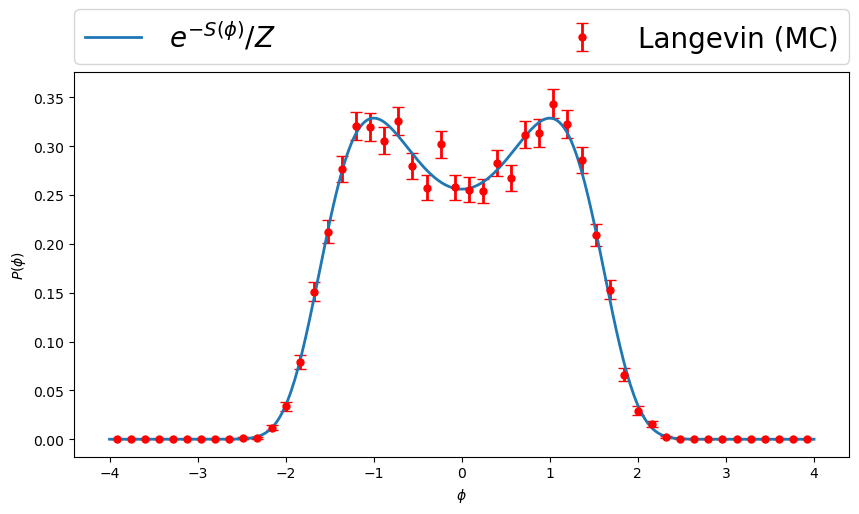

In [7]:
plot_hist(state1, model1)

In [9]:
state2 = SimState(n_seeds = int(1e4), device="cpu", dt_base = 1e-3)
model2 = SimModel(sigma=1, lamb=1)
evol2 = SimEvol(state2, model2)
runner2 = SimRunner(state2, model2, evol2)

for _ in tqdm(range(int(1e4))):
    runner2.step()
    # print(state2.alive_count, end = "\r")

runner2.finish()

1767048357.415628: [SimState] initialized
1767048357.416406: [scalar_phi4] initialized
1767048357.416524: [SimEvol] initialized
1767048357.4166179: [SimRunner] initialized


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [00:06<00:00, 1663.51it/s]

1767048363.430912: [SimRunner] simulation parameters: {'sigma': 1, 'lamb': 1}
1767048363.4309819: [SimRunner] Final alive count: 10000
1767048363.4310799: [SimRunner] Final average of langevin time: 1.0000e+01
1767048363.431211: [SimRunner] Final std of langevin time: 1.7764e-15
1767048363.431276: [SimRunner] Final average of dt_ada: 1.0000e+00
1767048363.4313548: [SimRunner] Final std of dt_ada: 0.0000e+00


In [10]:
%%timeit
runner2.step()

596 μs ± 1.82 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


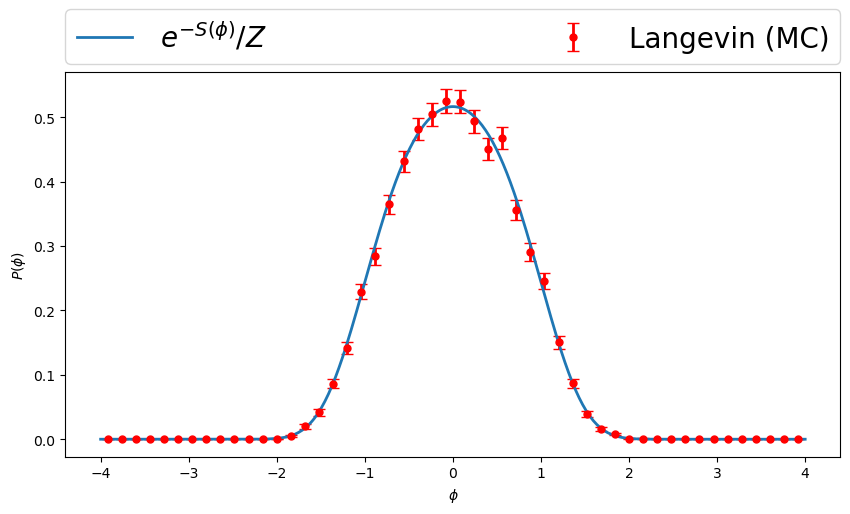

In [11]:
plot_hist(state2, model2)

In [12]:
%%timeit 
runner2.step()

599 μs ± 1.66 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
